# Results After Filtering — Module Similarity & Pathway Survival

Runs `tissue_specific_filtering.py` across thresholds for IID and STRING (GTEx and PaxDB sources), then evaluates the resulting filtered networks:
1. Non-brain tissue-specific genes are preferentially removed; brain-specific genes are retained
2. KEGG pathway gene survival across thresholds (with an unfiltered-network coverage baseline)
3. Downstream disease-module Jaccard similarity across pipeline runs

## 1 — Setup

In [2]:
import subprocess
import sys
import os
from pathlib import Path

import graph_tool.all as gt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from gprofiler import GProfiler

REPO_ROOT = Path(".").resolve()
SCRIPT    = REPO_ROOT / "diseasemodulediscovery/bin/tissue_specific_filtering.py"
BIN_DIR   = SCRIPT.parent
NET_DIR   = REPO_ROOT / "alzheimer_symbol_runs/alzheimer_run_symbol_threshold_1/input/networks"
EXPR_FILE = REPO_ROOT / "data/expression_by_tissue.gct"
OUT_ROOT  = REPO_ROOT / "sanity_check_outputs"

TISSUE     = "Brain_Hippocampus"
THRESHOLDS = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
NETWORKS   = {
    "iid":    NET_DIR / "iid.human.Symbol.gt",
    "string": NET_DIR / "string.human_links_v12_0_min900.Symbol.gt",
}

OUT_ROOT.mkdir(exist_ok=True)
print("Script:", SCRIPT)
print("Expression file:", EXPR_FILE)
print("Networks:", {k: v.name for k, v in NETWORKS.items()})

Script: /root/ba/diseasemodulediscovery/bin/tissue_specific_filtering.py
Expression file: /root/ba/data/expression_by_tissue.gct
Networks: {'iid': 'iid.human.Symbol.gt', 'string': 'string.human_links_v12_0_min900.Symbol.gt'}


## 2 — Run `tissue_specific_filtering.py` for each threshold × network (GTEx)

In [3]:
env = {**os.environ, "PYTHONPATH": str(BIN_DIR)}

run_index = {}  # (net_name, threshold) -> output_dir

for net_name, net_path in NETWORKS.items():
    for thr in THRESHOLDS:
        tag    = f"thr_{str(thr).replace('.', '_')}"
        outdir = OUT_ROOT / net_name / tag
        outdir.mkdir(parents=True, exist_ok=True)

        filtered_gt = outdir / f"{net_path.stem}.{TISSUE}.gt"
        if filtered_gt.exists():
            print(f"[skip] {net_name} thr={thr}  (already exists)")
            run_index[(net_name, thr)] = outdir
            continue

        cmd = [
            sys.executable, str(SCRIPT),
            "--network",                str(net_path),
            "--tissue",                 TISSUE,
            "--threshold",              str(thr),
            "--filtering_source",       "GTEx",
            "--custom_expression_file", "null",
            "--id_space",               "symbol",
        ]
        result = subprocess.run(cmd, cwd=str(outdir), env=env,
                                capture_output=True, text=True)
        if result.returncode != 0:
            print(f"ERROR {net_name} thr={thr}:\n{result.stderr[-2000:]}")
        else:
            print(f"[done] {net_name} thr={thr}")
        run_index[(net_name, thr)] = outdir

print("All runs complete.")

[skip] iid thr=0.1  (already exists)
[skip] iid thr=0.5  (already exists)
[skip] iid thr=1.0  (already exists)
[skip] iid thr=2.0  (already exists)
[skip] iid thr=5.0  (already exists)
[skip] iid thr=10.0  (already exists)
[skip] string thr=0.1  (already exists)
[skip] string thr=0.5  (already exists)
[skip] string thr=1.0  (already exists)
[skip] string thr=2.0  (already exists)
[skip] string thr=5.0  (already exists)
[skip] string thr=10.0  (already exists)
All runs complete.


## 3 — Collect filtering statistics from script output

In [4]:
stats_rows = []
for (net_name, thr), outdir in run_index.items():
    tsv = outdir / "filtering_statistic.tsv"
    if not tsv.exists():
        print(f"Missing: {tsv}")
        continue
    row = pd.read_csv(tsv, sep="\t").iloc[0].to_dict()
    row["network_name"] = net_name
    row["threshold"]    = thr
    stats_rows.append(row)

stats_df = pd.DataFrame(stats_rows)
# clean HTML from tissue column if present
stats_df["tissue"] = stats_df["tissue"].str.extract(r'>([^<]+)<', expand=False).fillna(stats_df["tissue"])
stats_df.sort_values(["network_name", "threshold"], inplace=True)
stats_df.head(12)

,network,tissue,genes_in_tissue,genes_not_in_network_absolute,genes_not_in_network_relative,genes_not_in_expression_file_absolute,genes_not_in_expression_file_relative,genes_filtered_by_threshold_absolute,genes_filtered_by_threshold_relative,network_name,threshold
0,iid.human.Symbol.Brain_Hippocampus,Brain_Hippocampus,19182,21143,0.537908,166,0.009057,2878,0.157019,iid,0.1
1,iid.human.Symbol.Brain_Hippocampus,Brain_Hippocampus,15544,21143,0.537908,166,0.009057,4478,0.244312,iid,0.5
2,iid.human.Symbol.Brain_Hippocampus,Brain_Hippocampus,13862,21143,0.537908,166,0.009057,5454,0.297561,iid,1.0
3,iid.human.Symbol.Brain_Hippocampus,Brain_Hippocampus,11865,21143,0.537908,166,0.009057,6911,0.377053,iid,2.0
4,iid.human.Symbol.Brain_Hippocampus,Brain_Hippocampus,8423,21143,0.537908,166,0.009057,10005,0.545856,iid,5.0
5,iid.human.Symbol.Brain_Hippocampus,Brain_Hippocampus,5444,21143,0.537908,166,0.009057,12865,0.701893,iid,10.0
6,string.human_links_v12_0_min900.Symbol.Brain_H...,Brain_Hippocampus,19182,27477,0.699054,98,0.008217,1506,0.126268,string,0.1
7,string.human_links_v12_0_min900.Symbol.Brain_H...,Brain_Hippocampus,15544,27477,0.699054,98,0.008217,2488,0.208602,string,0.5
8,string.human_links_v12_0_min900.Symbol.Brain_H...,Brain_Hippocampus,13862,27477,0.699054,98,0.008217,3055,0.256142,string,1.0
9,string.human_links_v12_0_min900.Symbol.Brain_H...,Brain_Hippocampus,11865,27477,0.699054,98,0.008217,3881,0.325396,string,2.0


## 4 — Extract node sets from original and filtered networks

In [5]:
def node_names(gt_path):
    g = gt.load_graph(str(gt_path))
    return {g.vp["name"][v] for v in g.iter_vertices()}

# cache original node sets
original_nodes = {name: node_names(path) for name, path in NETWORKS.items()}
print({k: len(v) for k, v in original_nodes.items()})

# collect retained and removed sets per (network, threshold)
node_sets = {}  # (net_name, thr) -> {"retained": set, "removed": set}
for (net_name, thr), outdir in run_index.items():
    net_path    = NETWORKS[net_name]
    filtered_gt = outdir / f"{net_path.stem}.{TISSUE}.gt"
    retained    = node_names(filtered_gt)
    removed     = original_nodes[net_name] - retained
    node_sets[(net_name, thr)] = {"retained": retained, "removed": removed}

print("Node sets collected for", len(node_sets), "runs.")

{'iid': 18329, 'string': 11927}
Node sets collected for 12 runs.


## 5 — Load GCT expression data (all tissues)

In [6]:
gct = pd.read_csv(EXPR_FILE, sep="\t", skiprows=2, header=0)
# Description column contains gene symbols; rename for clarity
gct = gct.rename(columns={"Name": "ensembl", "Description": "symbol"})
# strip Ensembl version suffixes
gct["ensembl"] = gct["ensembl"].str.split(".").str[0]

tissue_cols = [c for c in gct.columns if c not in ("ensembl", "symbol")]
print(f"{len(gct):,} genes × {len(tissue_cols)} tissues")
print("Brain tissues:", [t for t in tissue_cols if t.startswith("Brain")])

74,628 genes × 68 tissues
Brain tissues: ['Brain_Amygdala', 'Brain_Anterior_cingulate_cortex_BA24', 'Brain_Caudate_basal_ganglia', 'Brain_Cerebellar_Hemisphere', 'Brain_Cerebellum', 'Brain_Cortex', 'Brain_Frontal_Cortex_BA9', 'Brain_Hippocampus', 'Brain_Hypothalamus', 'Brain_Nucleus_accumbens_basal_ganglia', 'Brain_Putamen_basal_ganglia', 'Brain_Spinal_cord_cervical_c-1', 'Brain_Substantia_nigra']


## 6 — Tissue Contamination Analysis

For each reference non-brain tissue, define tissue-specific genes (TPM > 1 there, < 0.5 in Brain_Hippocampus) and measure what fraction are removed by the filter at each threshold.

In [7]:
REF_TISSUES = [
    "Liver", "Muscle_Skeletal", "Whole_Blood",
    "Kidney_Cortex", "Pancreas", "Heart_Left_Ventricle", "Lung",
]

# We use STRING as the reference network (smaller, cleaner)
NET = "string"
all_nodes = original_nodes[NET]

contamination_rows = []
for ref_tissue in REF_TISSUES:
    # tissue-specific: expressed in ref_tissue but not in brain
    tissue_specific_mask = (gct[ref_tissue] > 1) & (gct[TISSUE] < 0.5)
    tissue_specific_symbols = set(gct.loc[tissue_specific_mask, "symbol"].dropna())
    in_network = tissue_specific_symbols & all_nodes
    for thr in THRESHOLDS:
        removed = node_sets[(NET, thr)]["removed"]
        frac = len(tissue_specific_symbols & removed) / len(in_network) if in_network else 0.0
        contamination_rows.append({"tissue": ref_tissue, "threshold": thr,
                                    "frac_removed": frac,
                                    "n_tissue_specific_in_network": len(in_network)})

# positive control: brain-specific genes retained
brain_high = gct[TISSUE] > 1
other_low  = (gct[tissue_cols].drop(columns=[TISSUE]).max(axis=1) < 0.5)
brain_specific_symbols = set(gct.loc[brain_high & other_low, "symbol"].dropna())
brain_in_network = brain_specific_symbols & all_nodes
print(f"Brain-specific genes in network: {len(brain_in_network)}")

brain_retention = []
for thr in THRESHOLDS:
    retained = node_sets[(NET, thr)]["retained"]
    frac = len(brain_specific_symbols & retained) / len(brain_in_network) if brain_in_network else 0.0
    brain_retention.append({"threshold": thr, "frac_retained": frac})

cont_df   = pd.DataFrame(contamination_rows)
brain_ret = pd.DataFrame(brain_retention)
cont_df.head()

Brain-specific genes in network: 0


,tissue,threshold,frac_removed,n_tissue_specific_in_network
0,Liver,0.1,0.466527,478
1,Liver,0.5,1.000000,478
2,Liver,1.0,1.000000,478
3,Liver,2.0,1.000000,478
4,Liver,5.0,1.000000,478


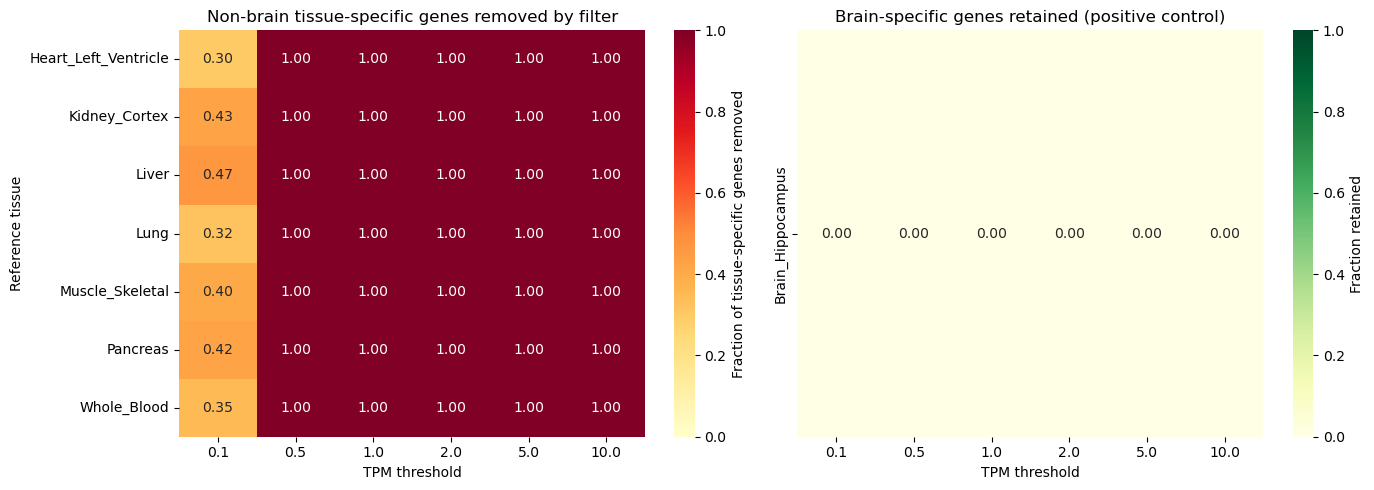

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: non-brain tissue removal heatmap
pivot = cont_df.pivot(index="tissue", columns="threshold", values="frac_removed")
sns.heatmap(
    pivot, ax=axes[0], annot=True, fmt=".2f",
    cmap="YlOrRd", vmin=0, vmax=1,
    cbar_kws={"label": "Fraction of tissue-specific genes removed"},
)
axes[0].set_title("Non-brain tissue-specific genes removed by filter")
axes[0].set_xlabel("TPM threshold")
axes[0].set_ylabel("Reference tissue")

# Right: brain-specific genes retained
pivot_b = brain_ret.set_index("threshold")[["frac_retained"]].T
sns.heatmap(
    pivot_b, ax=axes[1], annot=True, fmt=".2f",
    cmap="YlGn", vmin=0, vmax=1,
    cbar_kws={"label": "Fraction retained"},
)
axes[1].set_title("Brain-specific genes retained (positive control)")
axes[1].set_xlabel("TPM threshold")
axes[1].set_ylabel("")
axes[1].set_yticks([0.5])
axes[1].set_yticklabels(["Brain_Hippocampus"])

plt.tight_layout()
plt.savefig(OUT_ROOT / "tissue_contamination_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 7 — Tissue-Specific Pathway Gene Survival Across Thresholds (GTEx)

For a curated set of tissue-specific KEGG pathways, fetch the member genes and track how many remain in the filtered network at each threshold.
- **Non-brain pathways** (Liver, Pancreas, Heart, Blood, Kidney): expect progressive removal as threshold rises.
- **Brain pathways** (positive control): expect genes to remain.
- **Unfiltered column**: fraction of each pathway's full KEGG gene set already present in the raw, unfiltered network, independent of any threshold.

In [9]:
import requests
import re
import json

PATHWAYS = {
    # Non-brain — expect removal by brain filter
    "Insulin secretion (Pancreas)":           "hsa04911",
    "Bile secretion (Liver)":                 "hsa04976",
    "Drug metabolism CYP450 (Liver)":         "hsa00982",
    "Complement & coagulation (Blood)":       "hsa04610",
    "T cell receptor signaling (Immune)":     "hsa04660",
    "Cardiac muscle contraction (Heart)":     "hsa04260",
    "Aldosterone Na-reabsorption (Kidney)":   "hsa04960",
    # Brain — positive control, expect retention
    "Synaptic vesicle cycle (Brain)":         "hsa04721",
    "Dopaminergic synapse (Brain)":           "hsa04728",
    "Glutamatergic synapse (Brain)":          "hsa04724",
    "GABAergic synapse (Brain)":              "hsa04727",
    "Alzheimer disease (Brain)":              "hsa05010",
}

CACHE_FILE = OUT_ROOT / "kegg_pathway_genes.json"

def fetch_kegg_genes(pathway_id):
    """Return list of HGNC symbols from the GENE section of a KEGG pathway."""
    text = requests.get(f"https://rest.kegg.jp/get/{pathway_id}", timeout=30).text
    genes, in_gene = [], False
    for line in text.splitlines():
        if line.startswith("GENE"):
            in_gene = True
        elif in_gene and not line.startswith(" "):
            break
        if in_gene:
            m = re.search(r'\d+\s+(\S+);', line)
            if m:
                genes.append(m.group(1))
    return genes

if CACHE_FILE.exists():
    with open(CACHE_FILE) as f:
        pathway_genes = json.load(f)
    print("Loaded pathway gene lists from cache.")
else:
    pathway_genes = {}
    for name, pid in PATHWAYS.items():
        genes = fetch_kegg_genes(pid)
        pathway_genes[name] = genes
        print(f"  {pid}  {name}: {len(genes)} genes")
    with open(CACHE_FILE, "w") as f:
        json.dump(pathway_genes, f, indent=2)
    print("Cached to", CACHE_FILE)

for name, genes in pathway_genes.items():
    print(f"  {len(genes):3d}  {name}")


Loaded pathway gene lists from cache.
   86  Insulin secretion (Pancreas)
   90  Bile secretion (Liver)
   71  Drug metabolism CYP450 (Liver)
   89  Complement & coagulation (Blood)
  122  T cell receptor signaling (Immune)
   87  Cardiac muscle contraction (Heart)
   38  Aldosterone Na-reabsorption (Kidney)
   79  Synaptic vesicle cycle (Brain)
  133  Dopaminergic synapse (Brain)
  116  Glutamatergic synapse (Brain)
   89  GABAergic synapse (Brain)
  388  Alzheimer disease (Brain)


In [10]:
# ── Compute fraction of pathway genes surviving in the filtered network ──────
NON_BRAIN = [k for k in PATHWAYS if "(Brain)" not in k]
BRAIN     = [k for k in PATHWAYS if "(Brain)" in k]

rows = []
for net_name in NETWORKS:
    for pathway_name, genes in pathway_genes.items():
        gene_set      = set(genes)
        in_network    = gene_set & original_nodes[net_name]
        if not in_network:
            continue
        # "unfiltered" column: fraction of ALL pathway genes present in the
        # raw, unfiltered network — checks whether the pathway is even fully
        # covered by the network before any tissue filtering is applied.
        rows.append({
            "network":  net_name,
            "pathway":  pathway_name,
            "threshold": "unfiltered",
            "n_in_network": len(in_network),
            "n_surviving":  len(in_network),
            "frac_surviving": len(in_network) / len(gene_set),
        })
        for thr in THRESHOLDS:
            retained      = node_sets[(net_name, thr)]["retained"]
            n_surviving   = len(in_network & retained)
            rows.append({
                "network":  net_name,
                "pathway":  pathway_name,
                "threshold": thr,
                "n_in_network": len(in_network),
                "n_surviving":  n_surviving,
                "frac_surviving": n_surviving / len(in_network),
            })

survival_df = pd.DataFrame(rows)
print(survival_df.groupby(["network", "pathway"])[["n_in_network"]].first().to_string())


                                              n_in_network
network pathway                                           
iid     Aldosterone Na-reabsorption (Kidney)            37
        Alzheimer disease (Brain)                      383
        Bile secretion (Liver)                          89
        Cardiac muscle contraction (Heart)              87
        Complement & coagulation (Blood)                88
        Dopaminergic synapse (Brain)                   132
        Drug metabolism CYP450 (Liver)                  68
        GABAergic synapse (Brain)                       89
        Glutamatergic synapse (Brain)                  115
        Insulin secretion (Pancreas)                    85
        Synaptic vesicle cycle (Brain)                  78
        T cell receptor signaling (Immune)             120
string  Aldosterone Na-reabsorption (Kidney)            37
        Alzheimer disease (Brain)                      366
        Bile secretion (Liver)                          

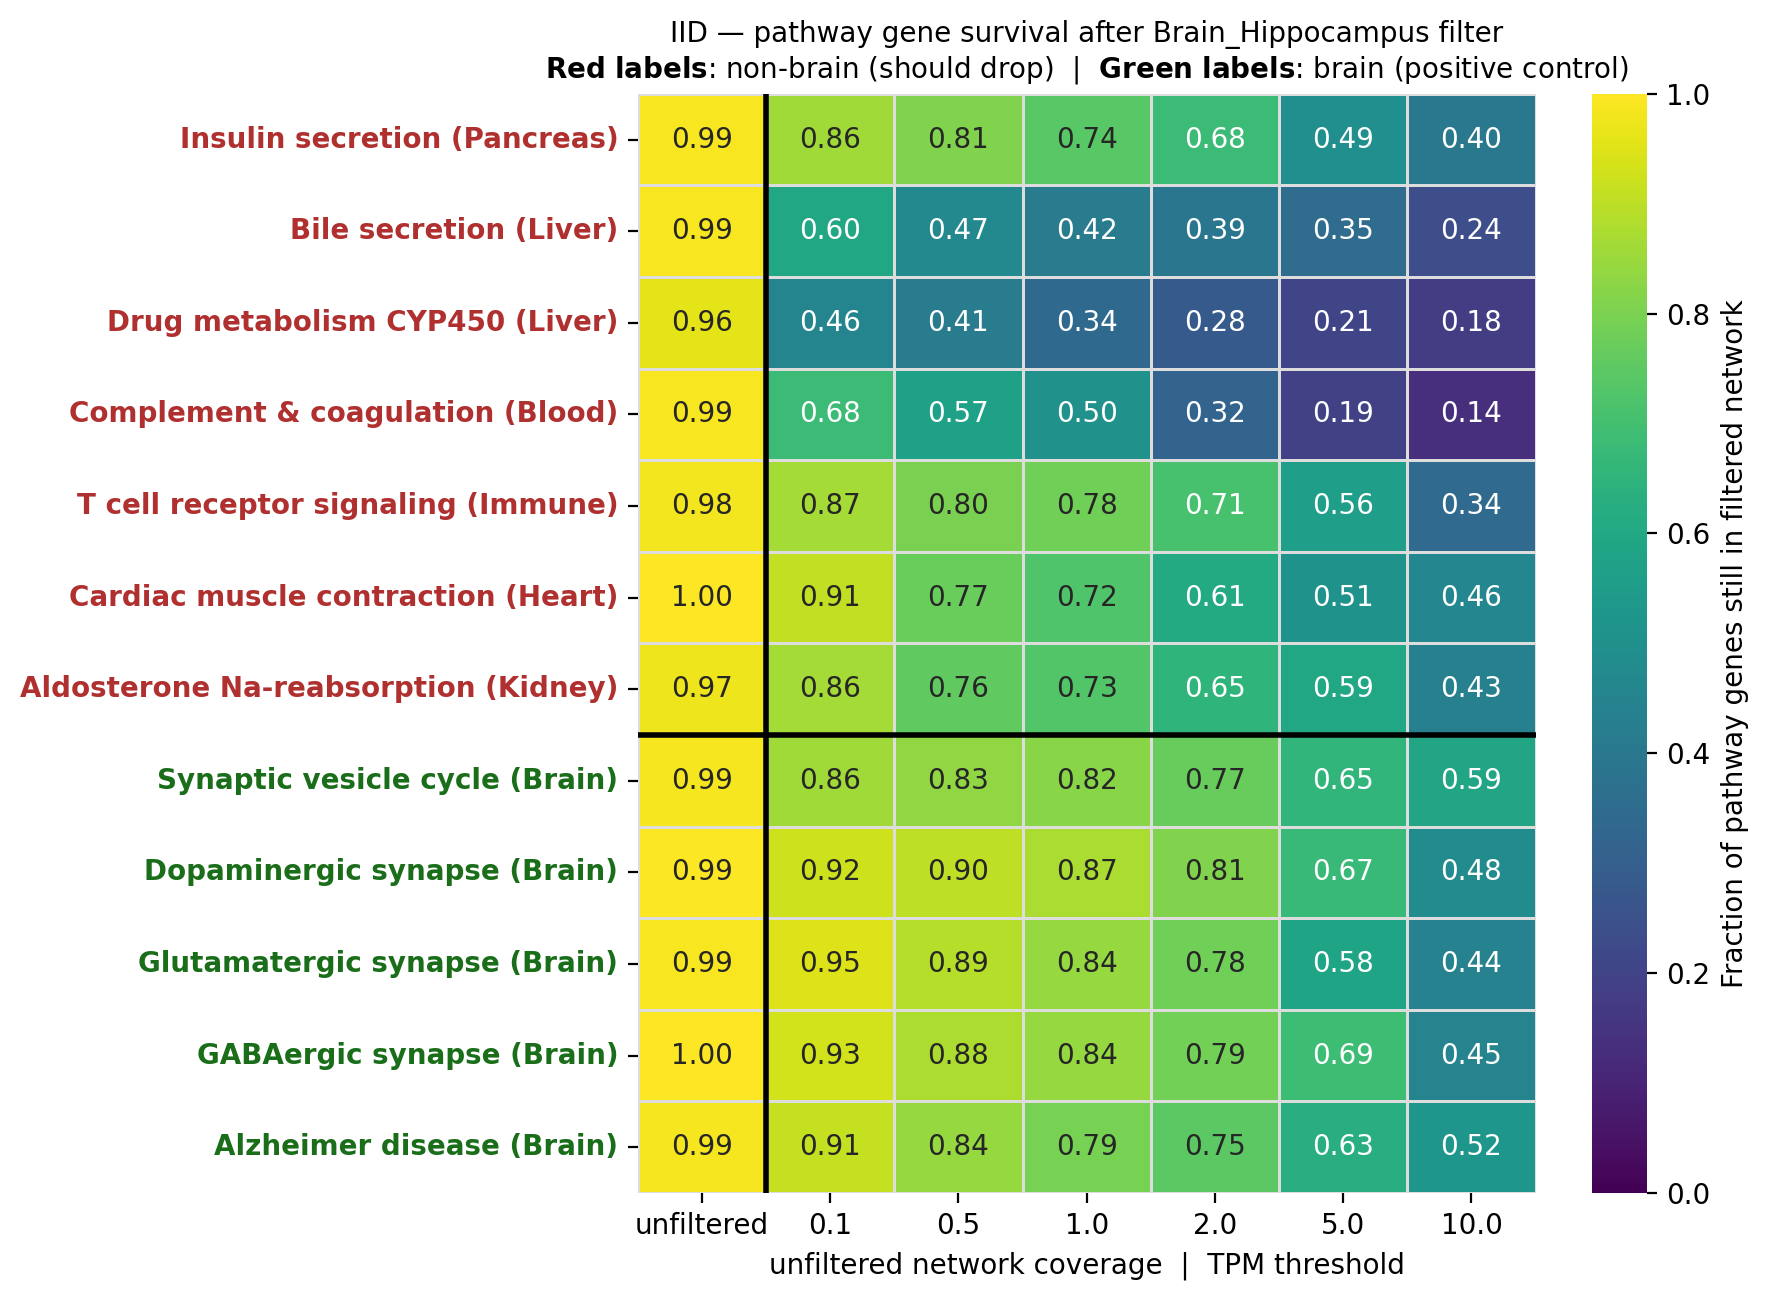

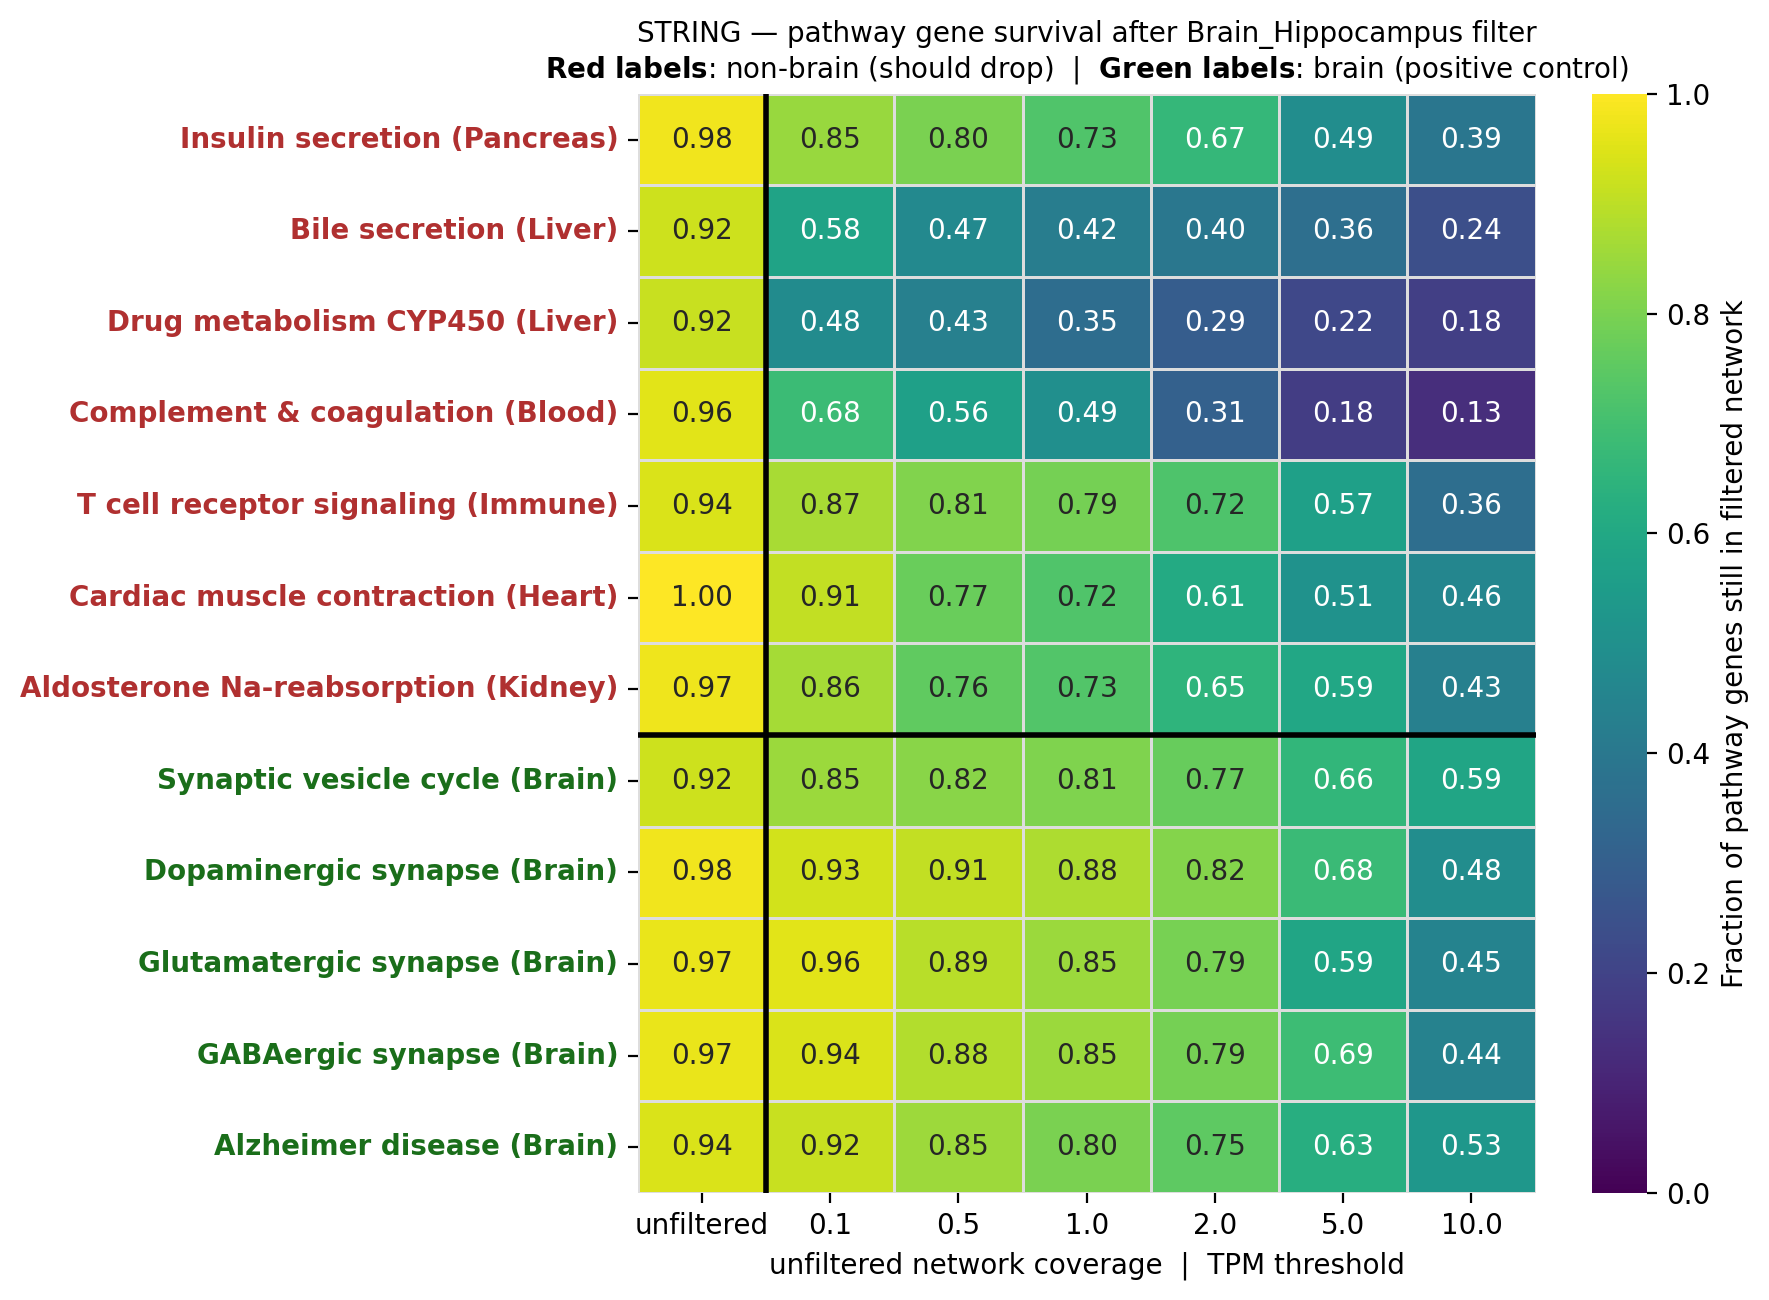

In [11]:
def pathway_survival_heatmap(df, net_name, outfile=None, filter_label="Brain_Hippocampus filter", xlabel="TPM threshold"):
    """Heatmap: rows = pathways (non-brain then brain), cols = unfiltered + thresholds, values = fraction surviving."""
    pivot = df[df["network"] == net_name].pivot(
        index="pathway", columns="threshold", values="frac_surviving"
    )
    numeric_thresholds = sorted(c for c in pivot.columns if c != "unfiltered")
    col_order = (["unfiltered"] if "unfiltered" in pivot.columns else []) + numeric_thresholds
    pivot = pivot[col_order]

    ordered     = [p for p in NON_BRAIN + BRAIN if p in pivot.index]
    pivot       = pivot.reindex(ordered)
    n_non_brain = sum(1 for p in ordered if "(Brain)" not in p)

    fig, ax = plt.subplots(figsize=(9, max(5, len(ordered) * 0.55)), dpi = 200)
    sns.heatmap(
        pivot, ax=ax,
        annot=True, fmt=".2f",
        cmap="viridis", vmin=0, vmax=1,
        linewidths=0.4, linecolor="#dddddd",
        cbar_kws={"label": "Fraction of pathway genes still in filtered network"},
    )
    ax.axhline(n_non_brain, color="black", lw=2)
    if "unfiltered" in col_order:
        ax.axvline(1, color="black", lw=2)

    # Color y-tick labels instead of floating text (avoids colorbar overlap)
    for tick, label in zip(ax.get_yticklabels(), ordered):
        tick.set_color("#b03030" if "(Brain)" not in label else "#1a6e1a")
        tick.set_fontweight("bold")

    ax.set_title(f"{net_name.upper()} — pathway gene survival after {filter_label}\n"
                 r"$\bf{Red\ labels}$: non-brain (should drop)  |  "
                 r"$\bf{Green\ labels}$: brain (positive control)",
                 fontsize=10)
    ax.set_xlabel(f"unfiltered network coverage  |  {xlabel}")
    ax.set_ylabel("")
    plt.tight_layout()
    if outfile:
        plt.savefig(outfile, dpi=150, bbox_inches="tight")
    plt.show()

for net_name in NETWORKS:
    pathway_survival_heatmap(
        survival_df, net_name,
        outfile=OUT_ROOT / f"pathway_survival_{net_name}.png",
    )


## 8 — PaxDB (BRAIN): Tissue-Specific Pathway Gene Survival Across Thresholds

Same analysis as Section 7, but using PaxDB integrated protein abundance (ppm) for `BRAIN` instead of GTEx TPM for `Brain_Hippocampus`. Uses the pipeline script's native `--filtering_source PAXDB`, so no local expression file is needed. Reuses `original_nodes`, `PATHWAYS`, and `pathway_genes` from Section 7 — only the filtering source and threshold scale change.

In [12]:
PAXDB_TISSUE     = "BRAIN"
PAXDB_THRESHOLDS = [0.1, 1.0, 5.0, 10.0, 50.0, 100.0]  # ppm
PAXDB_OUT_ROOT   = OUT_ROOT / "paxdb"
PAXDB_OUT_ROOT.mkdir(exist_ok=True)

print("PaxDB tissue:", PAXDB_TISSUE)
print("PaxDB thresholds (ppm):", PAXDB_THRESHOLDS)


PaxDB tissue: BRAIN
PaxDB thresholds (ppm): [0.1, 1.0, 5.0, 10.0, 50.0, 100.0]


In [13]:
paxdb_run_index = {}  # (net_name, threshold) -> output_dir

for net_name, net_path in NETWORKS.items():
    for thr in PAXDB_THRESHOLDS:
        tag    = f"thr_{str(thr).replace('.', '_')}"
        outdir = PAXDB_OUT_ROOT / net_name / tag
        outdir.mkdir(parents=True, exist_ok=True)

        filtered_gt = outdir / f"{net_path.stem}.{PAXDB_TISSUE}.gt"
        if filtered_gt.exists():
            print(f"[skip] {net_name} thr={thr}  (already exists)")
            paxdb_run_index[(net_name, thr)] = outdir
            continue

        cmd = [
            sys.executable, str(SCRIPT),
            "--network",                str(net_path),
            "--tissue",                 PAXDB_TISSUE,
            "--threshold",              str(thr),
            "--filtering_source",       "PAXDB",
            "--custom_expression_file", "null",
            "--id_space",               "symbol",
        ]
        result = subprocess.run(cmd, cwd=str(outdir), env=env,
                                capture_output=True, text=True)
        if result.returncode != 0:
            print(f"ERROR {net_name} thr={thr}:\n{result.stderr[-2000:]}")
        else:
            print(f"[done] {net_name} thr={thr}")
        paxdb_run_index[(net_name, thr)] = outdir

print("All PaxDB runs complete.")


[skip] iid thr=0.1  (already exists)
[skip] iid thr=1.0  (already exists)
[skip] iid thr=5.0  (already exists)
[skip] iid thr=10.0  (already exists)
[skip] iid thr=50.0  (already exists)
[skip] iid thr=100.0  (already exists)
[skip] string thr=0.1  (already exists)
[skip] string thr=1.0  (already exists)
[skip] string thr=5.0  (already exists)
[skip] string thr=10.0  (already exists)
[skip] string thr=50.0  (already exists)
[skip] string thr=100.0  (already exists)
All PaxDB runs complete.


In [14]:
paxdb_node_sets = {}  # (net_name, thr) -> {"retained": set, "removed": set}
for (net_name, thr), outdir in paxdb_run_index.items():
    net_path    = NETWORKS[net_name]
    filtered_gt = outdir / f"{net_path.stem}.{PAXDB_TISSUE}.gt"
    retained    = node_names(filtered_gt)
    removed     = original_nodes[net_name] - retained
    paxdb_node_sets[(net_name, thr)] = {"retained": retained, "removed": removed}

print("Node sets collected for", len(paxdb_node_sets), "PaxDB runs.")


Node sets collected for 12 PaxDB runs.


In [15]:
paxdb_rows = []
for net_name in NETWORKS:
    for pathway_name, genes in pathway_genes.items():
        gene_set   = set(genes)
        in_network = gene_set & original_nodes[net_name]
        if not in_network:
            continue
        paxdb_rows.append({
            "network":  net_name,
            "pathway":  pathway_name,
            "threshold": "unfiltered",
            "n_in_network": len(in_network),
            "n_surviving":  len(in_network),
            "frac_surviving": len(in_network) / len(gene_set),
        })
        for thr in PAXDB_THRESHOLDS:
            retained    = paxdb_node_sets[(net_name, thr)]["retained"]
            n_surviving = len(in_network & retained)
            paxdb_rows.append({
                "network":  net_name,
                "pathway":  pathway_name,
                "threshold": thr,
                "n_in_network": len(in_network),
                "n_surviving":  n_surviving,
                "frac_surviving": n_surviving / len(in_network),
            })

paxdb_survival_df = pd.DataFrame(paxdb_rows)
print(paxdb_survival_df.groupby(["network", "pathway"])[["n_in_network"]].first().to_string())


                                              n_in_network
network pathway                                           
iid     Aldosterone Na-reabsorption (Kidney)            37
        Alzheimer disease (Brain)                      383
        Bile secretion (Liver)                          89
        Cardiac muscle contraction (Heart)              87
        Complement & coagulation (Blood)                88
        Dopaminergic synapse (Brain)                   132
        Drug metabolism CYP450 (Liver)                  68
        GABAergic synapse (Brain)                       89
        Glutamatergic synapse (Brain)                  115
        Insulin secretion (Pancreas)                    85
        Synaptic vesicle cycle (Brain)                  78
        T cell receptor signaling (Immune)             120
string  Aldosterone Na-reabsorption (Kidney)            37
        Alzheimer disease (Brain)                      366
        Bile secretion (Liver)                          

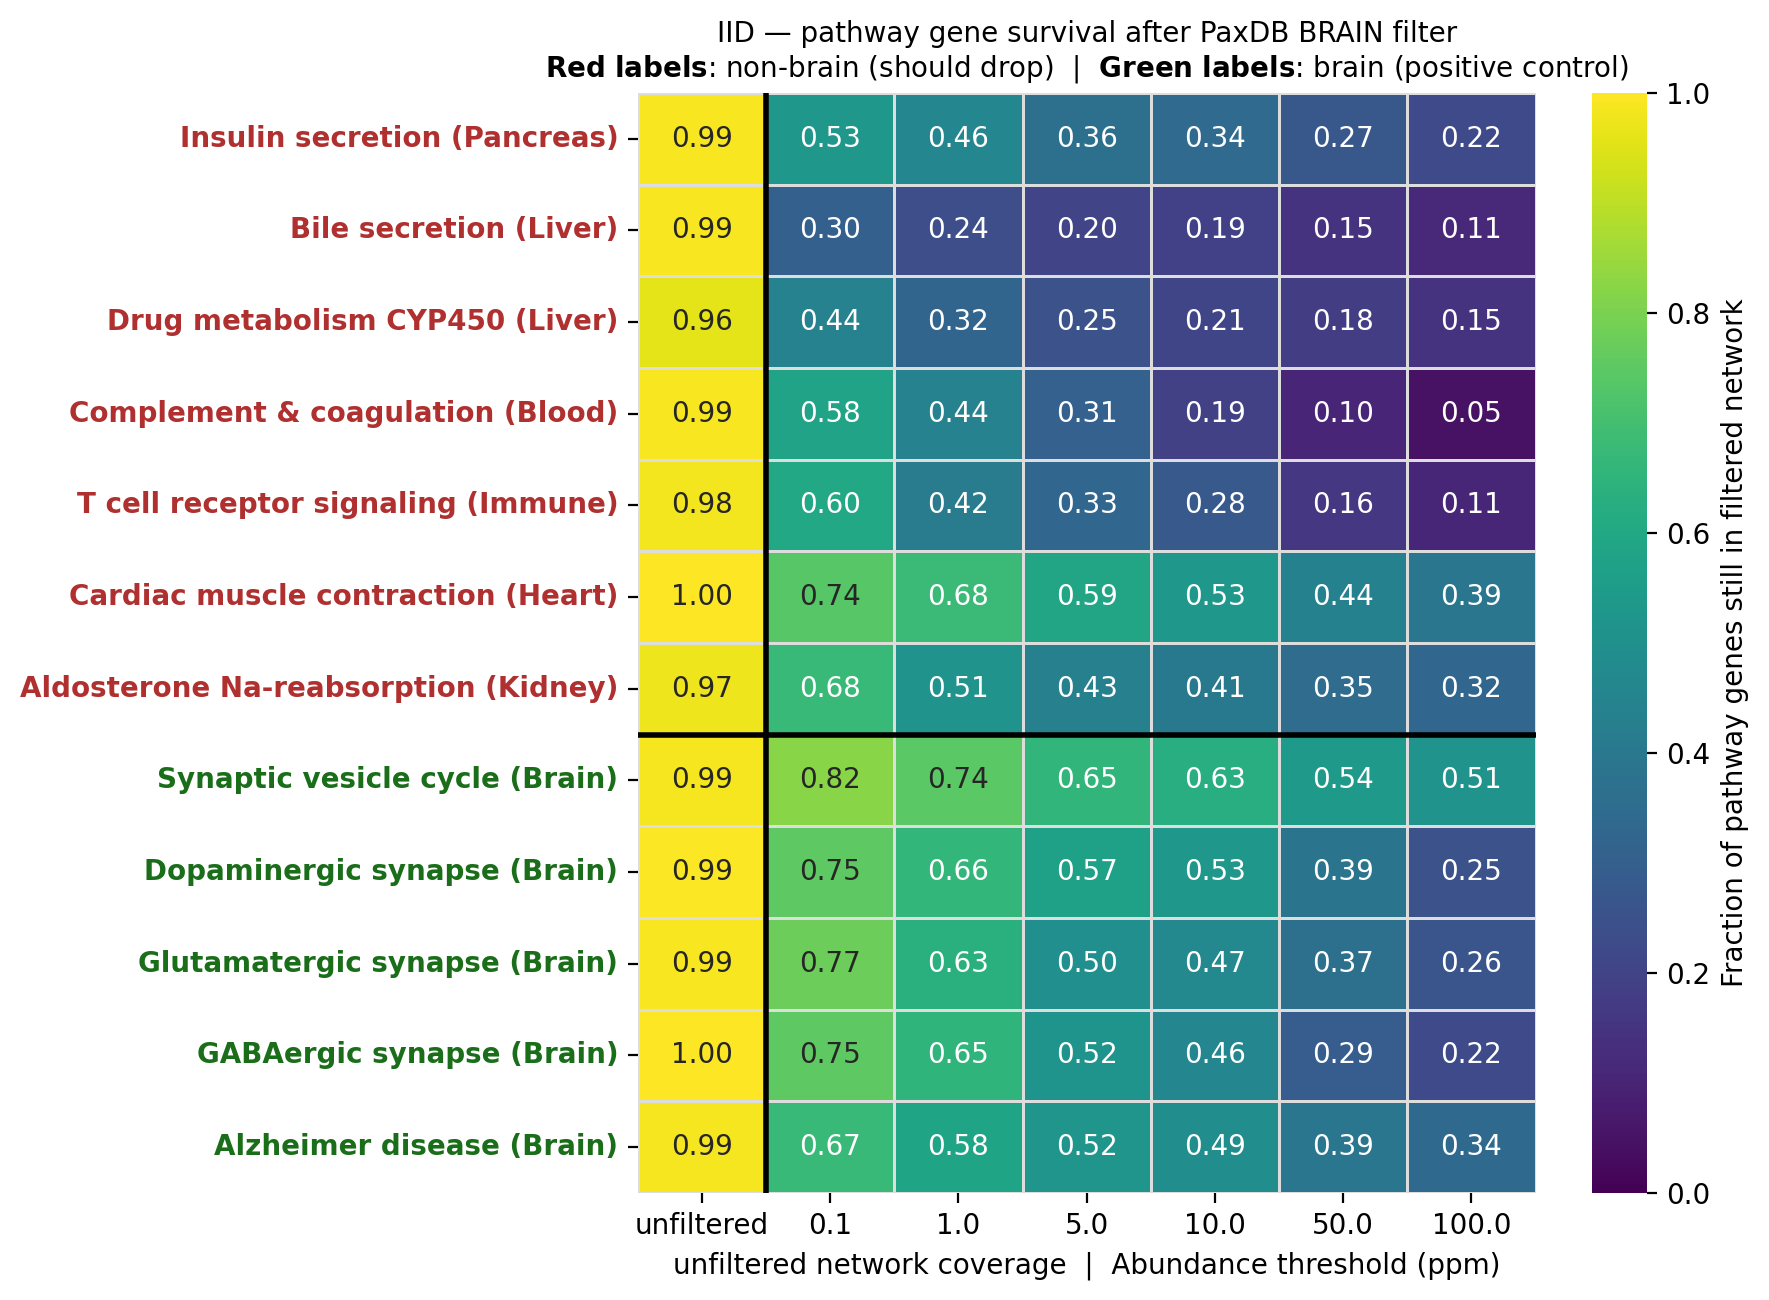

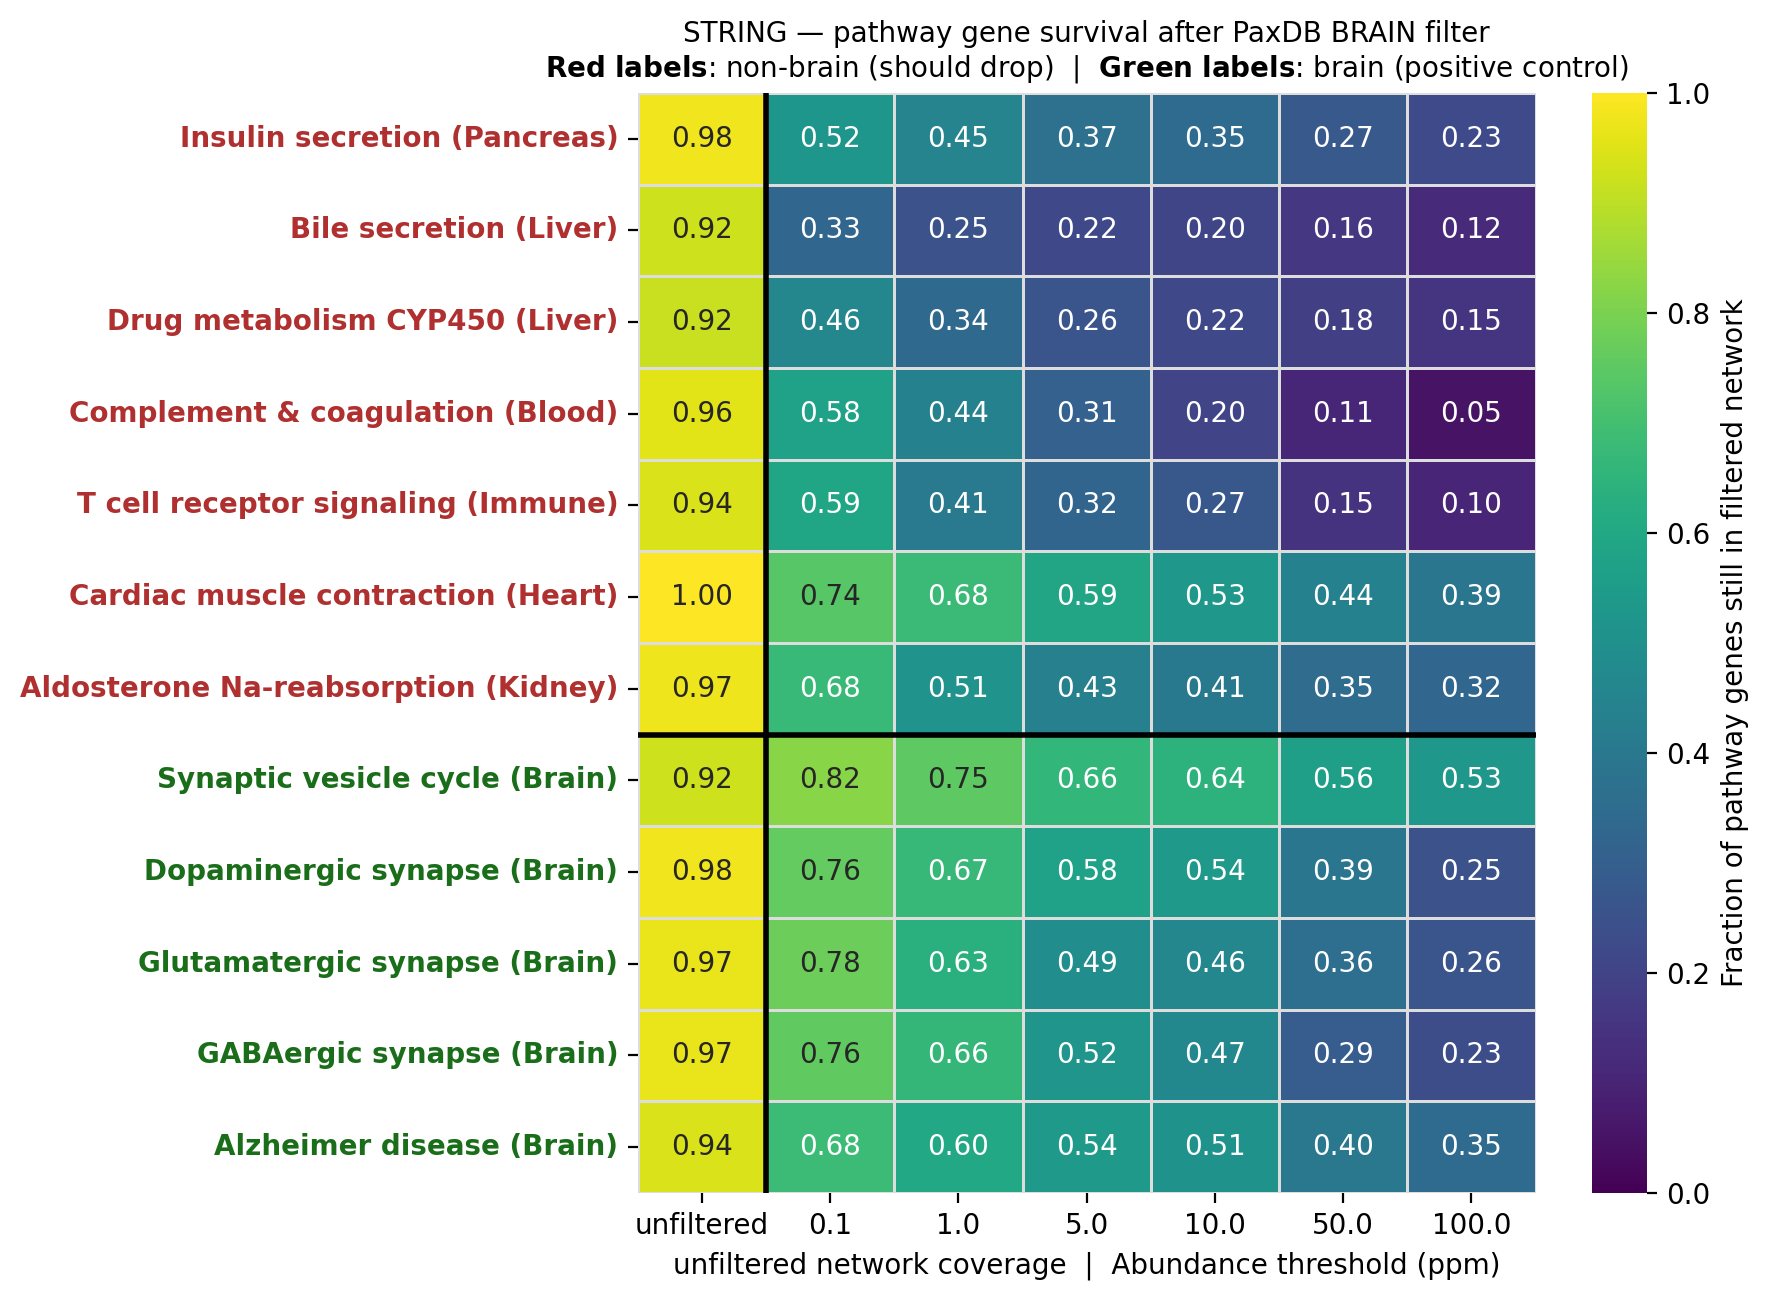

In [16]:
for net_name in NETWORKS:
    pathway_survival_heatmap(
        paxdb_survival_df, net_name,
        outfile=PAXDB_OUT_ROOT / f"pathway_survival_{net_name}_paxdb_brain.png",
        filter_label="PaxDB BRAIN filter",
        xlabel="Abundance threshold (ppm)",
    )


## 9 — Downstream Disease-Module Jaccard Similarity

Module overlap (Jaccard similarity, seeds excluded) across pipeline runs, from the pipeline's own MultiQC evaluation output. Hierarchically clustered for readability.

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

similarity_path = "data/jaccard_similarity_no_seeds_matrix_mqc.tsv"
similarity_df = pd.read_csv(similarity_path, sep="\t", index_col=0)

def simplify_sample_name(sample_name: str) -> str:
    parts = sample_name.split(".")
    tool = parts[-1]
    tissue = parts[-2] if len(parts) > 1 and "_" in parts[-2] else None
    return f"{tool} ({tissue})" if tissue else tool

labels = [simplify_sample_name(name) for name in similarity_df.index]
similarity_df.index = labels
similarity_df.columns = labels

# Cluster samples using hierarchical clustering on 1 - similarity.
distance_df = 1 - similarity_df
distance_df = (distance_df + distance_df.T) / 2
for idx in range(len(distance_df)):
    distance_df.iat[idx, idx] = 0.0

linkage_matrix = linkage(squareform(distance_df.to_numpy()), method="average", optimal_ordering=True)
cluster_order = leaves_list(linkage_matrix)
clustered_df = similarity_df.iloc[cluster_order, cluster_order]


sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(14, 8), dpi = 400, facecolor="white")
ax.set_facecolor("white")
sns.heatmap(clustered_df, cmap="RdYlBu_r", vmin=0, vmax=1, ax=ax, cbar_kws={"shrink": 0.85})
ax.set_title(f"Module Jaccard similarity (without seeds)\n{clustered_df.shape[0]} samples", fontsize=22)
ax.set_xticklabels(ax.get_xticklabels(), rotation=-45, ha="left")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'data/jaccard_similarity_no_seeds_matrix_mqc.tsv'

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

similarity_path = "data/jaccard_similarity_no_seeds_matrix_mqc.tsv"
raw_similarity_df = pd.read_csv(similarity_path, sep="\t", index_col=0)

def simplify_sample_name(sample_name: str) -> str:
    parts = sample_name.split(".")
    tool = parts[-1]
    tissue = parts[-2] if len(parts) > 1 and "_" in parts[-2] else None
    return f"{tool} (filtered)" if tissue else tool

def cluster_similarity_matrix(df: pd.DataFrame) -> pd.DataFrame:
    if df.shape[0] <= 1:
        return df
    distance_df = 1 - df
    distance_df = (distance_df + distance_df.T) / 2
    for idx in range(len(distance_df)):
        distance_df.iat[idx, idx] = 0.0
    linkage_matrix = linkage(squareform(distance_df.to_numpy()), method="average", optimal_ordering=True)
    cluster_order = leaves_list(linkage_matrix)
    ordered_labels = df.index[cluster_order].tolist()
    return df.loc[ordered_labels, ordered_labels]

network_label = "iid"
network_token = ".iid."

selected_samples = [sample for sample in raw_similarity_df.index if network_token in sample]
network_df = raw_similarity_df.loc[selected_samples, selected_samples].copy()
simplified_labels = [simplify_sample_name(sample) for sample in network_df.index]
network_df.index = simplified_labels
network_df.columns = simplified_labels
clustered_network_df = cluster_similarity_matrix(network_df)

sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(12, 10), dpi=400, facecolor="white")
ax.set_facecolor("white")

sns.heatmap(
    clustered_network_df,
    cmap="RdYlBu_r",
    vmin=0,
    vmax=1,
    ax=ax,
    cbar_kws={"shrink": 0.85},
)

ax.set_title(f"{network_label.upper()} \n{clustered_network_df.shape[0]} samples", fontsize=18)
ax.set_xticklabels(ax.get_xticklabels(), rotation=-45, ha="left", fontsize=14)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=14)

fig.suptitle("Module Jaccard similarity (without seeds)", fontsize=22, y=1.02)
plt.tight_layout()
plt.show()